In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# 將專案 root 加入 python path（讓 src/ 可以 import）
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)
print("✓ Imports ready")

Project root added: C:\Users\USER\Desktop\2026_japan
✓ Imports ready


In [2]:
from src.geo.grid_to_latlng import *

anchors = [
        {"x": 24, "y": 151, "lat": 43.06918333153887, "lng": 141.35147072116592},  # 札幌站 
        {"x": 24, "y": 148, "lat": 43.07940372979633, "lng": 141.34225589803765},  # 北海道大學
        {"x": 26, "y": 153, "lat": 43.05798589528942, "lng": 141.35402112326315},  # 狸小路商店街
        {"x": 52, "y": 81, "lat": 43.1982317547878, "lng": 140.99403634015297},  # 小樽站
        {"x": 50, "y": 41, "lat": 43.188064114901195, "lng": 140.79455411455163},  # 余市站
        {"x": 182, "y": 186, "lat": 43.85360951281324, "lng": 141.52348814480132},  # 増毛町文化センター
]

mapper = GridLatLngMapper(anchors)

In [3]:
import pandas as pd
from src.parks_create import *

df_pred = pd.read_parquet("../data/predictions/convlstm_df_pred.parquet")


In [4]:
g = urban_score(df_pred=df_pred)
g.head()


,x,y,mean_score,max_score,std_score,n,urban_score
0,1,22,0.965704,0.995430,0.018782,9,0.001782
1,1,23,1.194079,2.279464,0.523226,11,0.007045
2,1,24,1.104448,2.305912,0.324172,243,0.004979
3,1,25,1.125324,2.250246,0.354419,35,0.005460
4,1,34,1.453502,2.297386,0.646418,19,0.013023


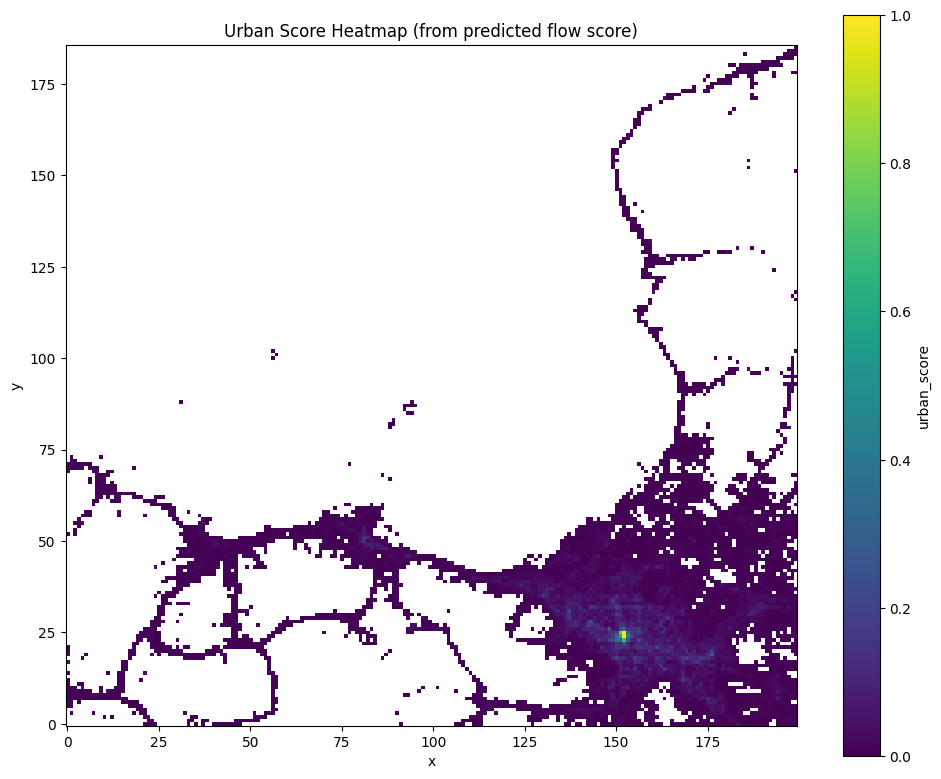

In [5]:
import matplotlib.pyplot as plt

# 轉成 2D 矩陣：row=y, col=x
mat = (g.pivot(index="y", columns="x", values="urban_score")
         .sort_index(axis=0)   # y 排序
         .sort_index(axis=1))  # x 排序
A = mat.values
A_90 = np.rot90(A, 3)
A_lr = np.fliplr(A_90)
plt.figure(figsize=(10, 8))
im = plt.imshow(A_lr, origin="lower", aspect="equal")
plt.colorbar(im, label="urban_score")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Urban Score Heatmap (from predicted flow score)")
plt.tight_layout()
plt.show()


In [6]:
south = 42.9
north = 43.9
west = 140.7
east = 141.6

df_poi = fetch_parking_pois_overpass(south, west, north, east)
df_poi.head()

,poi_id,lat,lng,name,parking,access,capacity_osm
0,node/1669817019,43.067234,141.347329,NaN,NaN,NaN,NaN
1,node/1682560396,43.106533,141.339452,三井のリパーク,multi-storey,NaN,351
2,node/1971133821,43.094295,141.510608,北のたまゆら江別店,NaN,NaN,NaN
3,node/2003840718,43.065726,141.349621,三井のリパーク,multi-storey,NaN,225
4,node/2003844199,43.065936,141.346998,タイムズ,multi-storey,NaN,392


In [7]:
# 保留公有停車場
df_poi_public = df_poi[df_poi["access"].isin([None, "yes", "customers", "permissive", "residents"])]

# NaN > 80% 蛋雕
df_poi_public = df_poi_public.drop(columns=["name", "capacity_osm"])

# 補上NaN
df_poi_public["parking"] = df_poi_public["parking"].fillna("surface")
df_poi_public["access"] = df_poi_public["access"].fillna("yes")

df_poi_public = df_poi_public.rename(columns={"parking" : "type"})
df_poi_public.head()

,poi_id,lat,lng,type,access
0,node/1669817019,43.067234,141.347329,surface,yes
1,node/1682560396,43.106533,141.339452,multi-storey,yes
2,node/1971133821,43.094295,141.510608,surface,yes
3,node/2003840718,43.065726,141.349621,multi-storey,yes
4,node/2003844199,43.065936,141.346998,multi-storey,yes


In [8]:
import folium
import pandas as pd

# 假設你的 df 叫 df_poi
# df_poi 有欄位: poi_id, lat, lng, name, parking, capacity_osm

fmap = folium.Map(location=[df_poi["lat"].mean(), df_poi["lng"].mean()], zoom_start=13)
c = 0
poi_limit = 100

for _, row in df_poi.iterrows():
    # 組 popup 內容
    c += 1
    if c > poi_limit:
        break

    name     = row["name"] if pd.notna(row["name"]) else "未命名停車場"
    parking  = row["parking"] if pd.notna(row["parking"]) else "N/A"
    capacity = int(row["capacity_osm"]) if pd.notna(row["capacity_osm"]) else "N/A"

    popup_html = (
        f"<b>{name}</b><br>"
        f"類型: {parking}<br>"
        f"容量: {capacity}<br>"
        f"poi_id: {row['poi_id']}"
    )

    folium.Marker(
        location=[row["lat"], row["lng"]],
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=name,
        icon=folium.Icon(color="blue", icon="car", prefix="fa"),
    ).add_to(fmap)

fmap.save("parking_poi.html")
print(f"✓ 地圖已輸出: parking_poi.html，共 {len(df_poi)} 個停車場")

✓ 地圖已輸出: parking_poi.html，共 4500 個停車場


In [9]:
import numpy as np
import pandas as pd

# 用百分位切
city_q = 0.7
city_threshold = g["urban_score"].quantile(city_q)

df_parks = synthesize_parking_lots_from_poi(
    g, 
    df_poi=df_poi_public, 
    mapper=mapper,
    seed=2025, 
    city_threshold=city_threshold
)
df_parks.to_csv("../data/parking lots/sapporo_synthetic_parking_lots.csv", index=False)
df_parks.head()

,park_id,grid_x,grid_y,park_x,park_y,park_lat,park_lng,urban_score,is_city,capacity,type,access
0,node/1669817019,24,150,24.396238,150.327510,43.067234,141.347329,0.240305,1,29,surface,yes
1,node/1682560396,32,149,32.319706,148.815222,43.106533,141.339452,0.041559,1,40,multi-storey,yes
2,node/1971133821,29,183,29.419872,182.636943,43.094295,141.510608,0.030919,1,40,surface,yes
3,node/2003840718,24,151,24.087080,150.778832,43.065726,141.349621,0.390566,1,28,multi-storey,yes
4,node/2003844199,24,150,24.135954,150.260492,43.065936,141.346998,0.240305,1,40,multi-storey,yes


In [10]:
# 市區/郊區數量對比
summary = (df_parks.groupby("is_city")
           .agg(n_parks=("park_id","count"),
                mean_cap=("capacity","mean"),
                med_cap=("capacity","median"),
                capacity=("capacity","sum"))
          )
summary['avg_cap'] = summary['capacity'] / summary['n_parks']
summary



,n_parks,mean_cap,med_cap,capacity,avg_cap
is_city,,,,,
0,947,89.963041,89.0,85195,89.963041
1,2981,29.950688,30.0,89283,29.950688


In [11]:
df_with_a = build_a(df_pred, g)
df_with_a.head()

,d,t,x,y,score,count,urban_score,date,weekday,is_weekend,z,a
0,32,18,1,22,0.938849,1,0.001782,2019-10-17,3,0,-1.429792,0.380873
1,26,20,1,22,0.978477,1,0.001782,2019-10-11,4,0,0.680091,0.375595
2,31,20,1,22,0.963455,1,0.001782,2019-10-16,2,0,-0.119743,0.356214
3,43,21,1,22,0.987735,1,0.001782,2019-10-28,0,0,1.172982,0.384444
4,52,21,1,22,0.956058,1,0.001782,2019-11-06,2,0,-0.513576,0.351463


            mean    median       std    count
zone                                         
city    0.354053  0.348397  0.040586  4312635
suburb  0.381431  0.378325  0.032148  1495902


C:\Users\USER\AppData\Local\Temp\ipykernel_13056\1964054801.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=zones, patch_artist=True,showfliers=False,


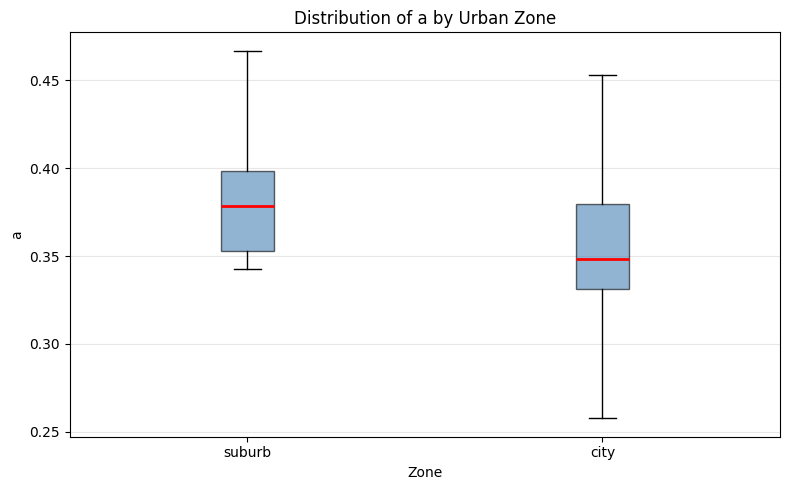

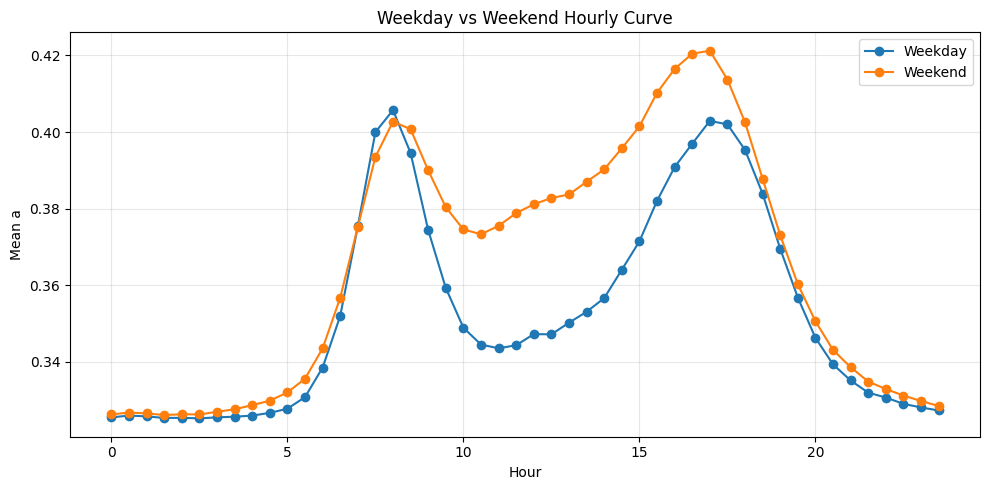

    z_bin    mean_a  median_a        n
0    z<=0  0.345356  0.343717  3156519
1  0<z<=1  0.366487  0.366485  1711160
2  1<z<=2  0.394023  0.396952   748246
3     z>2  0.443478  0.443574   192612
           score         a      cars
zone                                
city    3.418322  0.354053  1.173891
suburb  1.259559  0.381431  0.487856


In [12]:
import numpy as np
import pandas as pd

df = df_with_a.copy()
df["hour"] = df["t"] * 0.5

# merge urban_score（若 df 已有可略）
if "urban_score" not in df.columns:
    df = df.merge(g[["x","y","urban_score"]], on=["x","y"], how="left")


# B1) 市區 vs 郊區
df["zone"] = np.where(df["urban_score"] >= city_threshold, "city", "suburb")
print(df.groupby("zone")["a"].agg(["mean","median","std","count"]))

# 畫箱型圖
zones = ["suburb", "city"]
data  = [df[df["zone"] == z]["a"].dropna().values for z in zones]
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(data, labels=zones, patch_artist=True,showfliers=False,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           medianprops=dict(color="red", linewidth=2))

ax.set_xlabel("Zone")
ax.set_ylabel("a")
ax.set_title("Distribution of a by Urban Zone")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# B2) 時段曲線
curve = (df.groupby(["is_weekend","hour"])["a"].mean()
           .reset_index()
           .sort_values(["is_weekend","hour"]))
fig, ax = plt.subplots(figsize=(10, 5))

for is_weekend, group in curve.groupby("is_weekend"):
    label = "Weekend" if is_weekend else "Weekday"
    ax.plot(group["hour"], group["a"], marker="o", label=label)

ax.set_xlabel("Hour")
ax.set_ylabel("Mean a")
ax.set_title("Weekday vs Weekend Hourly Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# B3) Z分桶
# 分桶
bins   = [-np.inf, 0, 1, 2, np.inf]
labels = ["z<=0", "0<z<=1", "1<z<=2", "z>2"]
df["z_bin"] = pd.cut(df["z"], bins=bins, labels=labels, right=True)

# 每桶 mean(a)
res = (df.groupby("z_bin", observed=True)
         .agg(mean_a=("a","mean"),
              median_a=("a","median"),
              n=("a","size"))
         .reset_index())

print(res)

# C) cars 檢查
df["cars"] = df["a"] * df["score"]
print(df.groupby("zone")[["score","a","cars"]].mean())

In [13]:
df_prob = build_parking_prob_baseline(df_with_a, df_parks) # 約四十秒

# 把停車場位置/容量/市區標籤合併回來
df_prob = df_prob.merge(
    df_parks[["park_id", "park_x", "park_y", "capacity"] + 
             [c for c in ["is_city", "urban_score"] if c in df_parks.columns]],
    on="park_id",
    how="left"
)
df_prob.head()

,d,t,park_id,demand,pressure,p_avail,park_x,park_y,capacity,is_city,urban_score
0,32,18,node/10095286778,0.351773,0.012563,0.872653,23.862832,147.013421,28,1,0.098833
1,32,18,node/10188151756,5.375896,0.215036,0.670354,36.004512,136.971182,25,1,0.042484
2,32,18,node/10673369415,0.151916,0.005843,0.877067,21.511308,151.410173,26,1,0.163042
3,32,18,node/10674905656,0.158423,0.003961,0.878279,21.142992,151.374945,40,1,0.096687
4,32,18,node/11134318196,0.650758,0.029580,0.860868,21.383037,157.735259,22,1,0.076250


In [14]:
from src.parks_routing import aggregate_df_prob_same_weekday

df_prob_w = aggregate_df_prob_same_weekday(df_prob, agg="median")
df_prob_w

,w,t,park_id,p_avail,demand,pressure,park_x,park_y,capacity,is_city,urban_score
0,0,0,node/10095286778,0.879017,0.078611,0.002808,23.862832,147.013421,28,1,0.098833
1,0,0,node/10188151756,0.836790,1.522681,0.060907,36.004512,136.971182,25,1,0.042484
2,0,0,node/10673369415,0.879513,0.052744,0.002029,21.511308,151.410173,26,1,0.163042
3,0,0,node/10674905656,0.879936,0.054508,0.001363,21.142992,151.374945,40,1,0.096687
4,0,0,node/11134318196,0.875467,0.182645,0.008302,21.383037,157.735259,22,1,0.076250
...,...,...,...,...,...,...,...,...,...,...,...
1319803,6,47,way/993784993,0.880329,0.028179,0.000742,21.487757,144.509241,38,1,0.015764
1319804,6,47,way/993809191,0.878031,0.117369,0.004347,18.304010,153.859180,27,1,0.066262
1319805,6,47,way/993852658,0.880648,0.005448,0.000237,17.779563,148.398644,23,1,0.016289
1319806,6,47,way/994835895,0.880670,0.013468,0.000201,18.029155,149.065556,67,0,0.000918


In [15]:
# 每個時間片的總 car_demand
df_tmp = df_with_a.copy()
df_tmp["car_demand"] = 1.0 * df_tmp["a"].astype(float) * df_tmp["score"].astype(float)  # kappa=1.0時
total_flow = df_tmp.groupby(["d","t"])["car_demand"].sum().reset_index(name="total_car_demand")

# 每個時間片分配到停車場的總 demand
total_assigned = df_prob.groupby(["d","t"])["demand"].sum().reset_index(name="total_assigned_demand")

chk = total_flow.merge(total_assigned, on=["d","t"], how="left")
chk["assign_ratio"] = chk["total_assigned_demand"] / (chk["total_car_demand"] + 1e-12)

chk.head()

,d,t,total_car_demand,total_assigned_demand,assign_ratio
0,1,0,442.801244,441.773252,0.997678
1,1,1,434.726163,432.966339,0.995952
2,1,2,404.106113,403.418423,0.998298
3,1,3,367.803652,366.201543,0.995644
4,1,4,355.406905,354.648614,0.997866


13952256


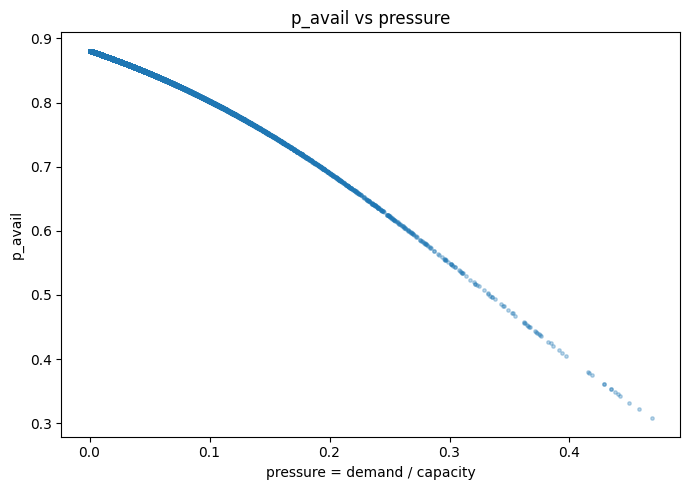

In [16]:
import matplotlib.pyplot as plt

print(len(df_prob))
sample = df_prob.sample(min(200000, len(df_prob)), random_state=0)

plt.figure(figsize=(7,5))
plt.scatter(sample["pressure"], sample["p_avail"], s=6, alpha=0.3)
plt.xlabel("pressure = demand / capacity")
plt.ylabel("p_avail")
plt.title("p_avail vs pressure")
plt.tight_layout()
plt.show()

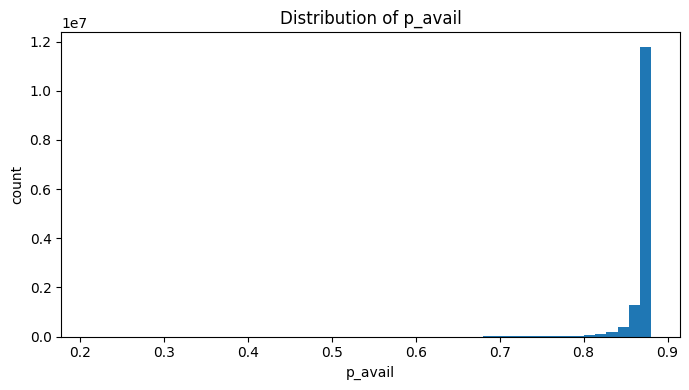

In [17]:
plt.figure(figsize=(7,4))
plt.hist(df_prob["p_avail"].to_numpy(), bins=50)
plt.xlabel("p_avail")
plt.ylabel("count")
plt.title("Distribution of p_avail")
plt.tight_layout()
plt.show()

mean p_avail by is_city:
 is_city
0    0.878158
1    0.870306
Name: p_avail, dtype: float64


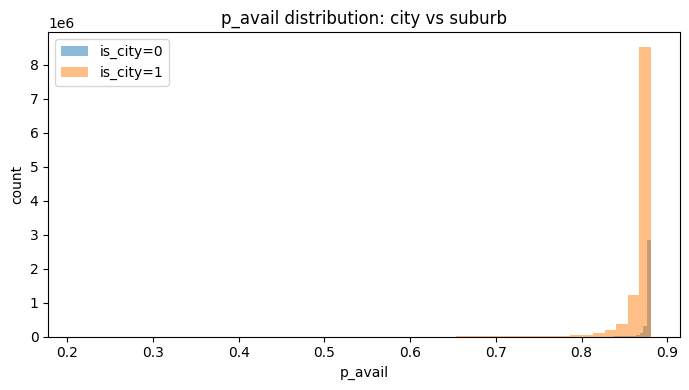

In [18]:
if "is_city" in df_prob.columns:
    g = df_prob.groupby("is_city")["p_avail"].mean()
    print("mean p_avail by is_city:\n", g)

    plt.figure(figsize=(7,4))
    for flag, sub in df_prob.groupby("is_city"):
        plt.hist(sub["p_avail"].to_numpy(), bins=50, alpha=0.5, label=f"is_city={flag}")
    plt.xlabel("p_avail")
    plt.ylabel("count")
    plt.title("p_avail distribution: city vs suburb")
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_13056\1775571324.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_13056\1775571324.py:14: UserWarning: Glyph 37066 (\N{CJK UNIFIED IDEOGRAPH-90CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_13056\1775571324.py:14: UserWarning: Glyph 21312 (\N{CJK UNIFIED IDEOGRAPH-5340}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_13056\1775571324.py:14: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\Desktop\2026_japan\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37066 (\N{CJK UNIFIED IDEOGRAPH-90CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

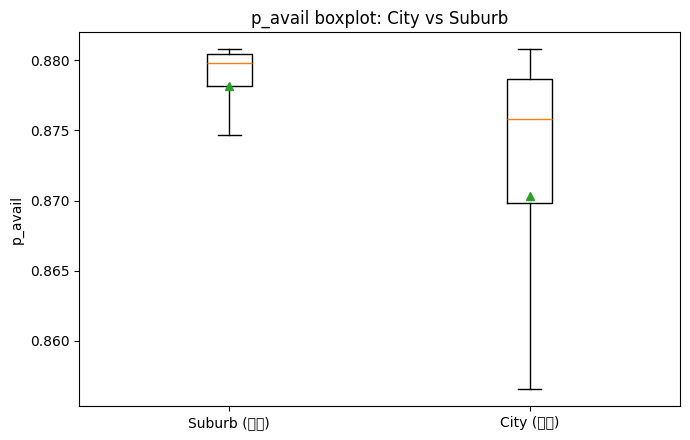

Suburb: {'n': 3363744, 'mean': 0.8781584727051845, 'median': 0.879796910293805, 'q1': 0.878160436095141, 'q3': 0.8804937585798787}
City  : {'n': 10588512, 'mean': 0.8703064583449974, 'median': 0.8757864761389071, 'q1': 0.8698031857165418, 'q3': 0.8786605022495299}


In [19]:
# 準備兩組資料
suburb = df_prob.loc[df_prob["is_city"] == 0, "p_avail"].dropna().to_numpy()
city   = df_prob.loc[df_prob["is_city"] == 1, "p_avail"].dropna().to_numpy()

plt.figure(figsize=(7, 4.5))
plt.boxplot(
    [suburb, city],
    labels=["Suburb (郊區)", "City (市區)"],
    showmeans=True,
    showfliers=False
)
plt.ylabel("p_avail")
plt.title("p_avail boxplot: City vs Suburb")
plt.tight_layout()
plt.show()

# （可選）印出摘要數字，方便你報告引用
def summary(arr):
    return {
        "n": len(arr),
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "q1": float(np.quantile(arr, 0.25)),
        "q3": float(np.quantile(arr, 0.75)),
    }

print("Suburb:", summary(suburb))
print("City  :", summary(city))

day 1 off-peak t= 7 peak t= 34


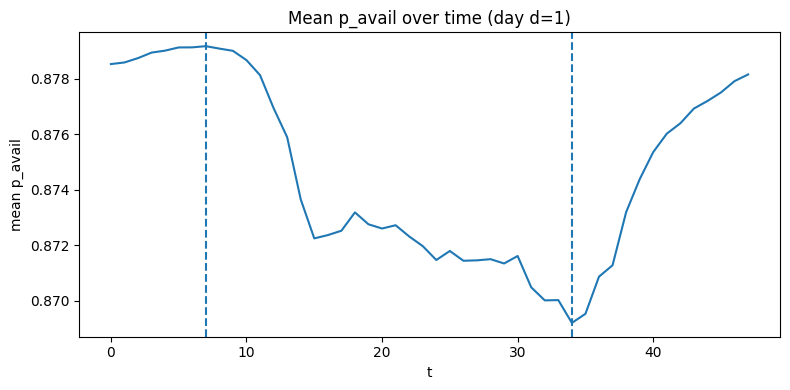

In [20]:
flow_by_t = (df_tmp.groupby(["d","t"])["car_demand"].sum().reset_index())
# 先挑某一天 d0（你也可以改成迴圈跑全部天）
d0 = int(flow_by_t["d"].min())
tmpd = flow_by_t[flow_by_t["d"] == d0].sort_values("car_demand")
t_off = int(tmpd.iloc[0]["t"])
t_peak = int(tmpd.iloc[-1]["t"])
print("day", d0, "off-peak t=", t_off, "peak t=", t_peak)

# 畫該天每個時間片的平均 p_avail
mean_p = (df_prob[df_prob["d"]==d0].groupby("t")["p_avail"].mean().reset_index())

plt.figure(figsize=(8,4))
plt.plot(mean_p["t"], mean_p["p_avail"])
plt.axvline(t_off, linestyle="--")
plt.axvline(t_peak, linestyle="--")
plt.xlabel("t")
plt.ylabel("mean p_avail")
plt.title(f"Mean p_avail over time (day d={d0})")
plt.tight_layout()
plt.show()

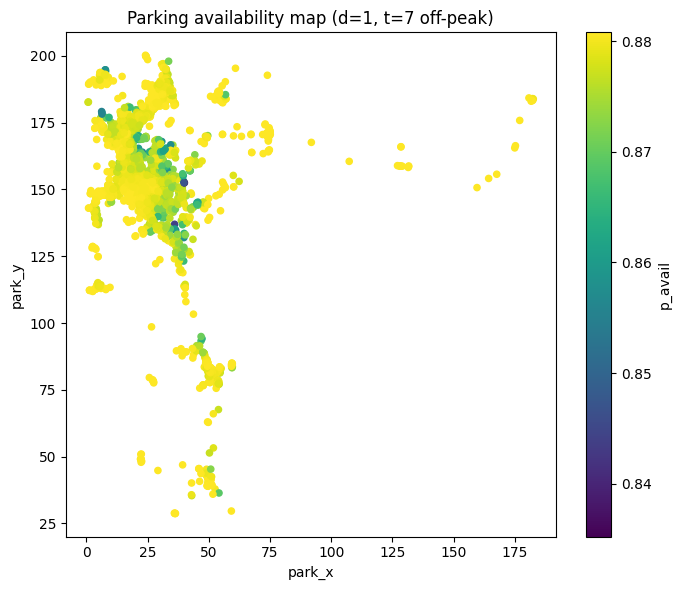

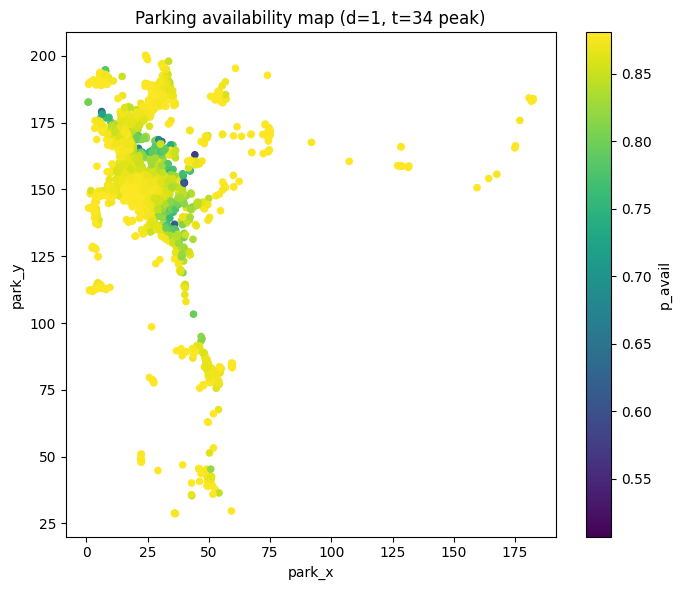

In [21]:
def plot_parks_map(df_prob, d, t, title):
    sub = df_prob[(df_prob["d"]==d) & (df_prob["t"]==t)].copy()
    plt.figure(figsize=(7,6))
    sc = plt.scatter(sub["park_x"], sub["park_y"], c=sub["p_avail"], s=20)
    plt.colorbar(sc, label="p_avail")
    plt.xlabel("park_x")
    plt.ylabel("park_y")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_parks_map(df_prob, d0, t_off,  f"Parking availability map (d={d0}, t={t_off} off-peak)")
plot_parks_map(df_prob, d0, t_peak, f"Parking availability map (d={d0}, t={t_peak} peak)")

In [22]:
from src.parks_choose import *

# 起點與終點座標
ox = 24
oy = 151
dx = 26
dy = 152

# 時間
d=32
t=12

cand = build_candidates(df_prob_w, mapper=mapper, w0=6, t0=t, O=(ox,oy), D=(dx,dy))
cand.head()

,park_id,w,t,p_avail,park_x,park_y,lat,lng,drive_time,walk_time,detour_time
0,node/10095286778,6,13,0.877980,23.862832,147.013421,43.064368,141.330582,2.813302,29.736232,30.518555
1,node/10188151756,6,13,0.751084,36.004512,136.971182,43.124091,141.279439,14.968989,102.922668,115.860678
2,node/10673369415,6,13,0.879336,21.511308,151.410173,43.052959,141.352889,2.372637,31.209125,31.550783
3,node/10674905656,6,13,0.879714,21.142992,151.374945,43.051126,141.352721,2.717263,33.762575,34.448859
4,node/11134318196,6,13,0.871991,21.383037,157.735259,43.052729,141.384885,5.325494,43.143125,46.437640


In [23]:
prefs = {
    "risk_aversion":0.1,
    
    "min_prob":0.01,
    "max_walk_min":120,
    "max_detour_min":120,

    "w_prob":0.4,
    "w_walk":0.2,
    "w_detour":0.2,
    "w_drive":0.3,
    "w_price":0.5,
}

parks = choose_parking(cand, prefs=prefs, top_k=5)
parks

,park_id,lat,lng,p_avail,drive_time,walk_time,detour_time,score,R,C_walk,C_detour,C_drive
906,way/1360082065,43.071934,141.355062,0.879408,1.399108,4.751330,4.119459,0.368449,1.003001,0.026432,0.018813,0.079009
395,way/1120633664,43.071634,141.353794,0.879598,1.278615,5.487554,4.735191,0.368442,1.003330,0.033304,0.024027,0.071413
2337,way/452081905,43.071788,141.354952,0.879497,1.367483,4.968328,4.304832,0.368389,1.003155,0.028458,0.020383,0.077015
2717,way/508300771,43.073310,141.352910,0.878883,1.555025,4.005956,3.530002,0.367527,1.002094,0.019475,0.013821,0.088838
348,way/1110297680,43.074551,141.353141,0.879157,1.793386,2.847563,2.609970,0.366929,1.002568,0.008663,0.006030,0.103865


In [24]:
K = 3

topk = (parks.sort_values(by=["score", "p_avail"], ascending=[False, False]).head(K).reset_index(drop=True))
topk.to_csv("../data/parking lots/topK_cand_parking_lots.csv", index=False)
topk

,park_id,lat,lng,p_avail,drive_time,walk_time,detour_time,score,R,C_walk,C_detour,C_drive
0,way/1360082065,43.071934,141.355062,0.879408,1.399108,4.751330,4.119459,0.368449,1.003001,0.026432,0.018813,0.079009
1,way/1120633664,43.071634,141.353794,0.879598,1.278615,5.487554,4.735191,0.368442,1.003330,0.033304,0.024027,0.071413
2,way/452081905,43.071788,141.354952,0.879497,1.367483,4.968328,4.304832,0.368389,1.003155,0.028458,0.020383,0.077015


In [25]:
import numpy as np
import folium
from folium.plugins import HeatMap

def parking_heatmap_map(
    df_t,
    center=None,
    use_expected=True,   # True: 用期望值；False: 用門檻法
    thr=0.6,             # 門檻法用
    radius=18,
    blur=15,
    tiles="OpenStreetMap",
    cap_log=True         # 容量權重太大時建議 log1p
):
    need_cols = {"lat","lng","p_avail","capacity"}
    miss = need_cols - set(df_t.columns)
    if miss:
        raise ValueError(f"df_t 缺少欄位: {sorted(miss)}")

    df = df_t.dropna(subset=["lat","lng","p_avail","capacity"]).copy()
    df["p_avail"] = df["p_avail"].clip(0, 1).astype(float)
    df["capacity"] = df["capacity"].astype(float)

    if use_expected:
        df["w_count"] = df["p_avail"]
        df["w_cap"]   = df["capacity"] * df["p_avail"]
        name_count = "可停車場數量(期望)"
        name_cap   = "可停車容量(期望車格數)"
    else:
        df["avail"]   = (df["p_avail"] >= thr).astype(float)
        df["w_count"] = df["avail"]
        df["w_cap"]   = df["capacity"] * df["avail"]
        name_count = f"可停車場數量(p_avail≥{thr})"
        name_cap   = f"可停車容量(p_avail≥{thr})"

    # 容量熱力圖常常被少數超大停車場支配 → 建議 log1p
    if cap_log:
        df["w_cap"] = np.log1p(df["w_cap"])

    # 讓權重落在 0~1（視覺比較穩）
    for col in ["w_count", "w_cap"]:
        mx = df[col].max()
        if mx > 0:
            df[col] = df[col] / mx

    if center is None:
        center = [float(df["lat"].mean()), float(df["lng"].mean())]

    m = folium.Map(location=center, zoom_start=13, tiles=tiles)

    fg_count = folium.FeatureGroup(name=name_count)
    fg_cap   = folium.FeatureGroup(name=name_cap)

    HeatMap(
        data=df[["lat","lng","w_count"]].values.tolist(),
        radius=radius, blur=blur, min_opacity=0.2, max_zoom=18
    ).add_to(fg_count)

    HeatMap(
        data=df[["lat","lng","w_cap"]].values.tolist(),
        radius=radius, blur=blur, min_opacity=0.2, max_zoom=18
    ).add_to(fg_cap)

    fg_count.add_to(m)
    fg_cap.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

    # 視野自動縮放到資料範圍
    m.fit_bounds([[df["lat"].min(), df["lng"].min()],
                  [df["lat"].max(), df["lng"].max()]])
    return m

target_d, target_t = 32, 18
df_t = df_prob[(df_prob["d"] == target_d) & (df_prob["t"] == target_t)].copy()
parks_xy = df_t.rename(columns={"park_x": "x", "park_y": "y"})[["x", "y"]]
parks_latlng = mapper.transform(parks_xy)

df_t["lat"] = parks_latlng["lat"].to_numpy()
df_t["lng"] = parks_latlng["lng"].to_numpy()

m = parking_heatmap_map(df_t, use_expected=True, cap_log=True)
m.save(f"parking_heatmap.html")
print("✓ 輸出完成")

✓ 輸出完成
